In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv(r"C:\Users\HP\Documents\Project For Data science\bakery_unclean_data.csv")

## DATA COLLECTION AND UNDERSTANDING

In [3]:
df.head()

,date,route_id,product_name,quantity_produced,quantity_dispatched,quantity_sold,quantity_returned,day_of_week,is_school_term,is_payday_cycle,notes
0,2026-04-16,route d,Mandazi,185.0,31.0,31.0,0.0,Thursday,0,1,NaN
1,03/02/2026,Route C,Bread,190.0,41.0,41.0,0.0,Tuesday,1,1,NaN
2,07/01/2026,Route C,Cake,171.0,35.0,35.0,0.0,Wednesday,1,0,NaN
3,03-24-2026,Route D,Mandazi,NaN,74.0,74.0,0.0,Tuesday,1,0,NaN
4,04/03/2026,Route D,Mandazi,330.0,60.0,60.0,0.0,Wed,1,0,NaN


In [4]:
# the columns of the dataset
df.shape[1]

11

In [5]:
# the rows of the dataset
df.shape[0]

2699

In [6]:
# displaying all the names and total number of variables
df.columns

Index(['date', 'route_id', 'product_name', 'quantity_produced',
       'quantity_dispatched', 'quantity_sold', 'quantity_returned',
       'day_of_week', 'is_school_term', 'is_payday_cycle', 'notes'],
      dtype='object')

In [7]:
# the imfomation about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2699 entries, 0 to 2698
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   date                 2699 non-null   object 
 1   route_id             2699 non-null   object 
 2   product_name         2699 non-null   object 
 3   quantity_produced    2649 non-null   float64
 4   quantity_dispatched  2647 non-null   float64
 5   quantity_sold        2612 non-null   float64
 6   quantity_returned    2633 non-null   float64
 7   day_of_week          2546 non-null   object 
 8   is_school_term       2699 non-null   object 
 9   is_payday_cycle      2699 non-null   object 
 10  notes                217 non-null    object 
dtypes: float64(4), object(7)
memory usage: 232.1+ KB


In [8]:
df.describe()

,quantity_produced,quantity_dispatched,quantity_sold,quantity_returned
count,2649.00000,2647.000000,2612.000000,2633.000000
mean,253.08456,50.783151,51.205972,-0.049373
std,146.05946,29.874198,30.365570,0.494491
min,-10.00000,7.000000,7.000000,-5.000000
25%,140.00000,28.000000,28.000000,0.000000
50%,219.00000,44.000000,44.000000,0.000000
75%,340.00000,67.500000,68.000000,0.000000
max,876.00000,196.000000,196.000000,0.000000


In [9]:
df.isnull().sum()

date                      0
route_id                  0
product_name              0
quantity_produced        50
quantity_dispatched      52
quantity_sold            87
quantity_returned        66
day_of_week             153
is_school_term            0
is_payday_cycle           0
notes                  2482
dtype: int64

## DATA CLEANING AND PREPARATION

In [10]:
#remove exact duplicates
initial_rows = len(df)
df.drop_duplicates(inplace = True)

In [11]:
df.isnull().sum()

date                      0
route_id                  0
product_name              0
quantity_produced        49
quantity_dispatched      50
quantity_sold            86
quantity_returned        64
day_of_week             150
is_school_term            0
is_payday_cycle           0
notes                  2433
dtype: int64

In [12]:
# standardize dates & reconstruct day of the week
df['date'] =pd.to_datetime(df['date'],format = 'mixed', dayfirst = True)
df['day_of_week'] = df['date'].dt.day_name()

In [13]:
df.isnull().sum()

date                      0
route_id                  0
product_name              0
quantity_produced        49
quantity_dispatched      50
quantity_sold            86
quantity_returned        64
day_of_week               0
is_school_term            0
is_payday_cycle           0
notes                  2433
dtype: int64

In [14]:
#clean & standardize categorical text
df['route_id'] = df['route_id'].astype(str).str.strip().str.title()
df['route_id']=df['route_id'].replace({'Rt' :'Route'})

In [15]:
df['product_name'] = df['product_name'].astype(str).str.strip().str.title()
df['product_name'] = df['product_name'].replace({'Bred':'Bread','Breads':'Bread','Mandazis':'Mandazi'})

In [16]:
# normalize booeln Indicators
bool_cols = ['is_school_term', 'is_payday_cycle']
for col in bool_cols:
    df[col] = df[col].astype(str).str.lower().str.strip()
    df[col] = df[col].map({'1': 1, '0': 0, 'yes': 1, 'no': 0, 'true': 1, 'false': 0})
    df[col] = df[col].fillna(0).astype(int)

In [17]:
df.isnull().sum()

date                      0
route_id                  0
product_name              0
quantity_produced        49
quantity_dispatched      50
quantity_sold            86
quantity_returned        64
day_of_week               0
is_school_term            0
is_payday_cycle           0
notes                  2433
dtype: int64

In [18]:
#handle missing values
df['quantity_produced'] =df['quantity_produced'].ffill()

In [19]:
df['quantity_dispatched'] =df['quantity_dispatched'].ffill()

In [20]:
df['quantity_sold'] =df['quantity_sold'].ffill()

In [21]:
df['quantity_returned'] =df['quantity_returned'].ffill()

In [22]:
df['quantity_dispatched'] =df['quantity_dispatched'].ffill()

In [23]:
df['notes'] =df['notes'].ffill()

In [24]:
df.isnull().sum()

date                   0
route_id               0
product_name           0
quantity_produced      0
quantity_dispatched    0
quantity_sold          0
quantity_returned      0
day_of_week            0
is_school_term         0
is_payday_cycle        0
notes                  9
dtype: int64

In [25]:
df['notes'] =df['notes'].bfill()

In [26]:
df.isnull().sum()

date                   0
route_id               0
product_name           0
quantity_produced      0
quantity_dispatched    0
quantity_sold          0
quantity_returned      0
day_of_week            0
is_school_term         0
is_payday_cycle        0
notes                  0
dtype: int64

In [27]:
# Median imputation grouped by product to preserve route/product baselines
df[col] = df.groupby('product_name')[col].transform(lambda x: x.fillna(x.median()))

In [28]:
df.isnull().sum()

date                   0
route_id               0
product_name           0
quantity_produced      0
quantity_dispatched    0
quantity_sold          0
quantity_returned      0
day_of_week            0
is_school_term         0
is_payday_cycle        0
notes                  0
dtype: int64

In [29]:
# winsorize extreme outliers at 99th percentile
upper_bound = df[col].quantile(0.99)
df[col] = df[col].clip(upper=upper_bound)

In [30]:
# fix logical errors ; sold > dispached
logical_fix = df['quantity_sold'] > df['quantity_dispatched']
df.loc[logical_fix, 'quantity_sold']=df.loc[logical_fix, 'quantity_dispatched']
df.loc[logical_fix, 'quantity_returned'] = 0

In [31]:
#future engineering
df['is_weekend'] = df['day_of_week'].isin(['Saturday', 'Sunday']).astype(int)
df['waste_to_sales_ratio'] = df['quantity_returned'] / (df['quantity_sold'] + 1e-5)
df['fulfillment_rate'] = df['quantity_sold'] / (df['quantity_dispatched'] + 1e-5)

In [32]:
# assign hypothetical unit cost for financial loss calculation
unit_costs ={'Bread': 60 , 'Cake':130, 'Mandazi' :50}
df['financial_loss_ksh'] = df['product_name'].map(unit_costs) * df['quantity_returned']

In [33]:
# assemble final dataset
df.to_csv('BAKERY CLEAN.csv')

In [34]:
df.head()

,date,route_id,product_name,quantity_produced,quantity_dispatched,quantity_sold,quantity_returned,day_of_week,is_school_term,is_payday_cycle,notes,is_weekend,waste_to_sales_ratio,fulfillment_rate,financial_loss_ksh
0,2026-04-16,Route D,Mandazi,185.0,31.0,31.0,0.0,Thursday,0,1,Truck broke down,0,0.0,1.0,0.0
1,2026-02-03,Route C,Bread,190.0,41.0,41.0,0.0,Tuesday,1,1,Truck broke down,0,0.0,1.0,0.0
2,2026-01-07,Route C,Cake,171.0,35.0,35.0,0.0,Wednesday,1,0,Truck broke down,0,0.0,1.0,0.0
3,2026-03-24,Route D,Mandazi,171.0,74.0,74.0,0.0,Tuesday,1,0,Truck broke down,0,0.0,1.0,0.0
4,2026-03-04,Route D,Mandazi,330.0,60.0,60.0,0.0,Wednesday,1,0,Truck broke down,0,0.0,1.0,0.0


In [35]:
df.drop(columns = ['notes'], inplace=True)

In [36]:
df.head()

,date,route_id,product_name,quantity_produced,quantity_dispatched,quantity_sold,quantity_returned,day_of_week,is_school_term,is_payday_cycle,is_weekend,waste_to_sales_ratio,fulfillment_rate,financial_loss_ksh
0,2026-04-16,Route D,Mandazi,185.0,31.0,31.0,0.0,Thursday,0,1,0,0.0,1.0,0.0
1,2026-02-03,Route C,Bread,190.0,41.0,41.0,0.0,Tuesday,1,1,0,0.0,1.0,0.0
2,2026-01-07,Route C,Cake,171.0,35.0,35.0,0.0,Wednesday,1,0,0,0.0,1.0,0.0
3,2026-03-24,Route D,Mandazi,171.0,74.0,74.0,0.0,Tuesday,1,0,0,0.0,1.0,0.0
4,2026-03-04,Route D,Mandazi,330.0,60.0,60.0,0.0,Wednesday,1,0,0,0.0,1.0,0.0


In [37]:
df.drop(columns = ['date'],inplace=True)

In [38]:
df.columns

Index(['route_id', 'product_name', 'quantity_produced', 'quantity_dispatched',
       'quantity_sold', 'quantity_returned', 'day_of_week', 'is_school_term',
       'is_payday_cycle', 'is_weekend', 'waste_to_sales_ratio',
       'fulfillment_rate', 'financial_loss_ksh'],
      dtype='object')

## EXPLORATORY DATA ANALYSIS(EDA)

In [39]:
# set visualizatiom sytle
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

In [40]:
df = pd.read_csv('BAKERY CLEAN.csv')

In [66]:
#descriptive statictics
df.select_dtypes(include = ('int','float'))

,Unnamed: 0,quantity_produced,quantity_dispatched,quantity_sold,quantity_returned,is_school_term,is_payday_cycle,is_weekend,waste_to_sales_ratio,fulfillment_rate,financial_loss_ksh
0,0,185.0,31.0,31.0,0.0,0,1,0,0.000000,1.0,0.0
1,1,190.0,41.0,41.0,0.0,1,1,0,0.000000,1.0,0.0
2,2,171.0,35.0,35.0,0.0,1,0,0,0.000000,1.0,0.0
3,3,171.0,74.0,74.0,0.0,1,0,0,0.000000,1.0,0.0
4,4,330.0,60.0,60.0,0.0,1,0,0,0.000000,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
2641,2693,595.0,122.0,122.0,0.0,1,0,0,0.000000,1.0,0.0
2642,2695,324.0,70.0,70.0,0.0,1,1,0,0.000000,1.0,0.0
2643,2696,361.0,85.0,85.0,0.0,1,0,1,0.000000,1.0,0.0
2644,2697,220.0,41.0,41.0,-5.0,1,1,1,-0.121951,1.0,-300.0


In [67]:
numericals = df.select_dtypes(include = ('int', 'float'))

In [68]:
numericals

,Unnamed: 0,quantity_produced,quantity_dispatched,quantity_sold,quantity_returned,is_school_term,is_payday_cycle,is_weekend,waste_to_sales_ratio,fulfillment_rate,financial_loss_ksh
0,0,185.0,31.0,31.0,0.0,0,1,0,0.000000,1.0,0.0
1,1,190.0,41.0,41.0,0.0,1,1,0,0.000000,1.0,0.0
2,2,171.0,35.0,35.0,0.0,1,0,0,0.000000,1.0,0.0
3,3,171.0,74.0,74.0,0.0,1,0,0,0.000000,1.0,0.0
4,4,330.0,60.0,60.0,0.0,1,0,0,0.000000,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
2641,2693,595.0,122.0,122.0,0.0,1,0,0,0.000000,1.0,0.0
2642,2695,324.0,70.0,70.0,0.0,1,1,0,0.000000,1.0,0.0
2643,2696,361.0,85.0,85.0,0.0,1,0,1,0.000000,1.0,0.0
2644,2697,220.0,41.0,41.0,-5.0,1,1,1,-0.121951,1.0,-300.0


In [69]:
numericals.corr()

,Unnamed: 0,quantity_produced,quantity_dispatched,quantity_sold,quantity_returned,is_school_term,is_payday_cycle,is_weekend,waste_to_sales_ratio,fulfillment_rate,financial_loss_ksh
Unnamed: 0,1.000000,-0.007445,-0.016187,-0.012317,0.002732,-0.004245,-0.023026,0.018008,0.024411,0.021644,0.014972
quantity_produced,-0.007445,1.000000,0.927446,0.924379,0.023016,0.037071,0.131389,0.150963,0.050554,-0.002426,0.044904
quantity_dispatched,-0.016187,0.927446,1.000000,0.975711,0.021917,0.034059,0.135950,0.152775,0.050764,-0.096984,0.042868
quantity_sold,-0.012317,0.924379,0.975711,1.000000,0.022575,0.035858,0.137981,0.152566,0.050621,0.110030,0.042482
quantity_returned,0.002732,0.023016,0.021917,0.022575,1.000000,0.035182,-0.015783,0.015061,0.873187,0.001958,0.914688
is_school_term,-0.004245,0.037071,0.034059,0.035858,0.035182,1.000000,-0.000714,0.011072,0.011098,0.007382,0.024059
is_payday_cycle,-0.023026,0.131389,0.135950,0.137981,-0.015783,-0.000714,1.000000,0.017822,-0.009353,0.013115,-0.010105
is_weekend,0.018008,0.150963,0.152775,0.152566,0.015061,0.011072,0.017822,1.000000,0.015206,-0.005191,0.006978
waste_to_sales_ratio,0.024411,0.050554,0.050764,0.050621,0.873187,0.011098,-0.009353,0.015206,1.000000,-0.002581,0.939349
fulfillment_rate,0.021644,-0.002426,-0.096984,0.110030,0.001958,0.007382,0.013115,-0.005191,-0.002581,1.000000,-0.003525


In [70]:
import scipy
from scipy import stats as st
st.pearsonr(df.quantity_produced, df.quantity_dispatched)

PearsonRResult(statistic=np.float64(0.9274456711364758), pvalue=np.float64(0.0))

In [71]:
df.describe()

,Unnamed: 0,quantity_produced,quantity_dispatched,quantity_sold,quantity_returned,is_school_term,is_payday_cycle,is_weekend,waste_to_sales_ratio,fulfillment_rate,financial_loss_ksh
count,2646.000000,2646.000000,2646.000000,2646.000000,2646.000000,2646.000000,2646.000000,2646.000000,2646.000000,2646.000000,2600.000000
mean,1337.366969,252.473167,50.713530,49.869615,-0.051020,0.832955,0.334089,0.289494,-0.001547,0.988091,-4.173077
std,777.641451,146.221084,29.735029,29.570498,0.502588,0.373086,0.471760,0.453613,0.017447,0.083253,44.545596
min,0.000000,-10.000000,7.000000,7.000000,-5.000000,0.000000,0.000000,0.000000,-0.416666,0.097826,-650.000000
25%,664.250000,139.000000,28.000000,27.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,1332.500000,218.000000,44.000000,43.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,2007.250000,340.000000,67.750000,67.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000
max,2698.000000,876.000000,196.000000,196.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000


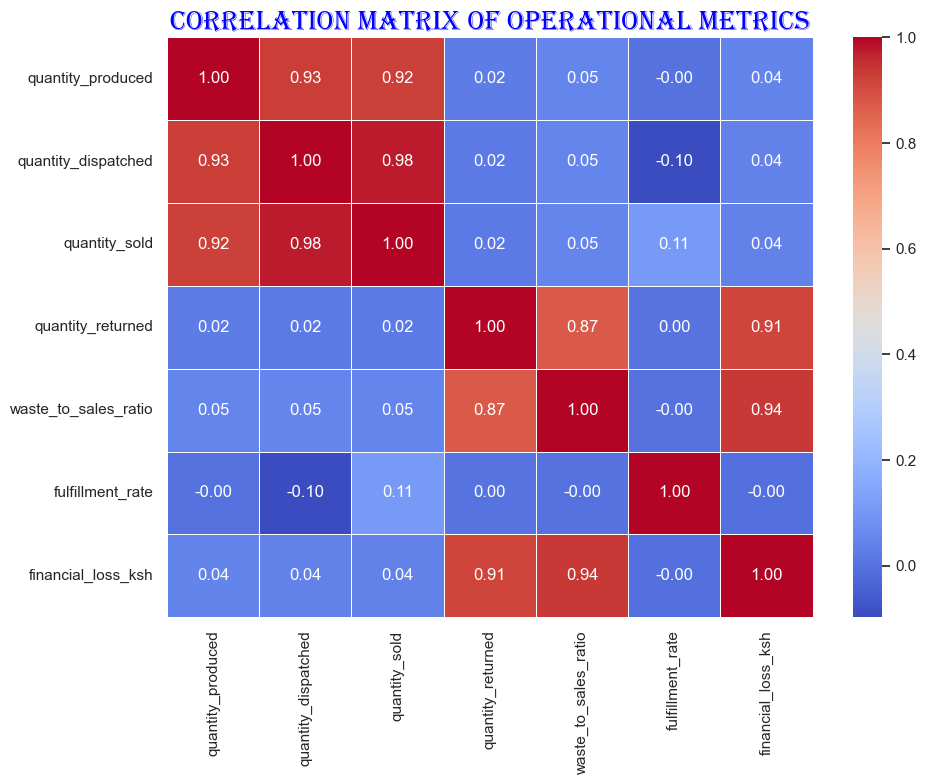

In [44]:
# correlation matrix
plt.figure(figsize=(10, 8))
corr_matrix = df[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Operational Metrics' ,fontsize = 20,fontname = 'Algerian',c = 'blue')
plt.tight_layout()
plt.show()

<Axes: ylabel='quantity_produced'>

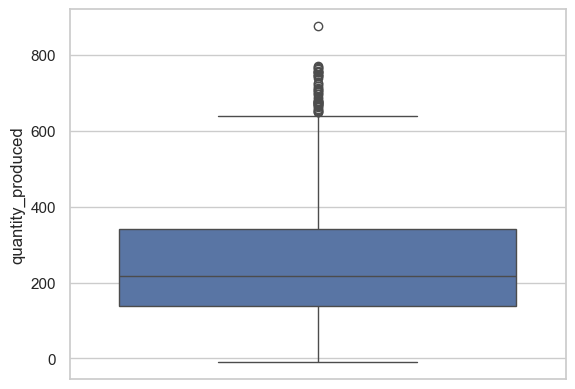

In [74]:
sns.boxplot(y = 'quantity_produced' , data = df)

In [76]:
Q3 =df.quantity_produced.quantile(0.75)
print(Q3)

340.0


In [77]:
Q1 =df.quantity_produced.quantile(0.25)
print(Q1)

139.0


In [78]:
IQR = Q3 - Q1
lower_limit = Q1 - 1.5*IQR
upper_limit = Q3 + 1.5*IQR

In [81]:
df[(df['quantity_produced']< lower_limit) | (df['quantity_produced'] > upper_limit)]

,Unnamed: 0,date,route_id,product_name,quantity_produced,quantity_dispatched,quantity_sold,quantity_returned,day_of_week,is_school_term,is_payday_cycle,notes,is_weekend,waste_to_sales_ratio,fulfillment_rate,financial_loss_ksh
15,15,2026-02-25,Route C,Mandazi,711.0,137.0,137.0,0.0,Wednesday,1,1,Truck broke down,0,0.0,1.000000,0.0
56,56,2026-05-16,Rt B,Mandazi,772.0,154.0,154.0,0.0,Saturday,1,1,Machine breakdown,1,0.0,1.000000,0.0
116,116,2026-03-06,Route B,Mandazi,676.0,117.0,117.0,0.0,Friday,1,0,Rainy day,0,0.0,1.000000,0.0
121,121,2026-05-17,Route C,Mandazi,672.0,160.0,160.0,0.0,Sunday,1,0,Rainy day,1,0.0,1.000000,0.0
139,139,2026-02-15,Route E,Mandazi,709.0,156.0,156.0,0.0,Sunday,1,1,Truck broke down,1,0.0,1.000000,0.0
140,140,2026-01-10,Route B,Mandazi,658.0,135.0,135.0,0.0,Saturday,1,0,Truck broke down,1,0.0,1.000000,0.0
175,175,2026-06-07,Route A,Mandazi,748.0,120.0,120.0,0.0,Sunday,1,0,Oven 2 was off,1,0.0,1.000000,0.0
243,243,2026-06-07,Route E,Mandazi,739.0,150.0,150.0,0.0,Sunday,1,0,Machine breakdown,1,0.0,1.000000,0.0
282,282,2026-02-20,Route E,Mandazi,653.0,149.0,149.0,0.0,Friday,1,0,Oven 2 was off,0,0.0,1.000000,0.0
299,299,2026-03-26,Route E,Mandazi,670.0,157.0,157.0,0.0,Thursday,1,1,Rainy day,0,0.0,1.000000,0.0


In [87]:
df = df[(df['quantity_produced'] >=lower_limit)& (df['quantity_produced'] <=upper_limit)]

In [88]:
df.quantity_produced.mean()

np.float64(244.92354975028812)